# Лабораторна робота №8
Студент групи Кіб-23011б  
<span style="color:red;">Олійник Дмитро Володимирович</span>  
**Варіант 6**

In [1]:
import platform
import os
import sys

print("Інформація про ОС:", platform.platform())
print("Шлях до папки проєкту:", os.path.abspath('.'))
print("Назва віртуального оточення:", os.path.basename(sys.prefix))

Інформація про ОС: Linux-6.8.0-1052-azure-x86_64-with-glibc2.39
Шлях до папки проєкту: /workspaces/pytlab8/oliinyk
Назва віртуального оточення: oliinyk


In [2]:
import numpy as np

np.random.seed(42)

additional_count = int(60 * 0.4)
remaining_count = 60 - additional_count - 2

positive_part = np.random.randint(1, 256, size=additional_count)
other_part = np.random.randint(-255, 256, size=remaining_count)
last_two = np.random.randint(-255, 0, size=2)

arr = np.concatenate([positive_part, other_part, last_two])
np.random.shuffle(arr)

print("Згенерований масив (60 елементів):")
print(arr)

np.save('array_data.npy', arr)
print("\nМасив успішно збережено у файл 'array_data.npy'.")

Згенерований масив (60 елементів):
[  21  -20   93  -66  -86 -197   88  208  211  103  152  -95  190  188
   53  107  204   58   75   38  -27 -201    2   15  -68   88  117  255
  219  122   89  215 -205   64  -64  249   72  190  -12   -3  100  108
 -234   21  220 -205  130  131  180  158 -125  -81  203  236   15  104
 -207  103  150  189]

Масив успішно збережено у файл 'array_data.npy'.


In [3]:
loaded_arr = np.load('array_data.npy')
print("Зчитаний з файлу масив:")
print(loaded_arr)

Зчитаний з файлу масив:
[  21  -20   93  -66  -86 -197   88  208  211  103  152  -95  190  188
   53  107  204   58   75   38  -27 -201    2   15  -68   88  117  255
  219  122   89  215 -205   64  -64  249   72  190  -12   -3  100  108
 -234   21  220 -205  130  131  180  158 -125  -81  203  236   15  104
 -207  103  150  189]


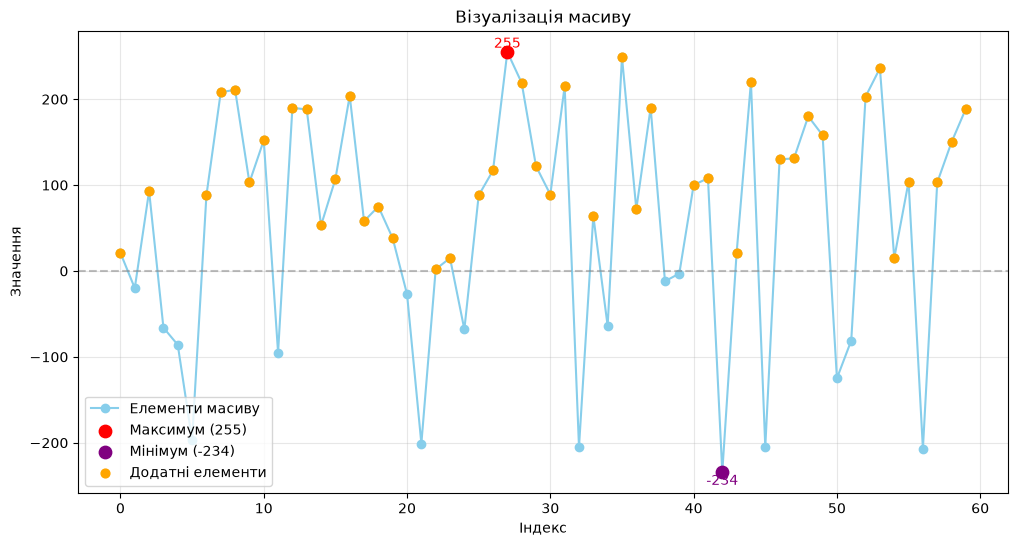

In [4]:
import matplotlib.pyplot as plt

max_val = np.max(loaded_arr)
min_val = np.min(loaded_arr)

plt.figure(figsize=(12, 6))
plt.plot(loaded_arr, marker='o', linestyle='-', color='skyblue', label='Елементи масиву')

max_indices = np.where(loaded_arr == max_val)[0]
min_indices = np.where(loaded_arr == min_val)[0]
pos_indices = np.where(loaded_arr > 0)[0]

plt.scatter(max_indices, [max_val]*len(max_indices), color='red', s=80, zorder=5, label=f'Максимум ({max_val})')
plt.scatter(min_indices, [min_val]*len(min_indices), color='purple', s=80, zorder=5, label=f'Мінімум ({min_val})')
plt.scatter(pos_indices, loaded_arr[pos_indices], color='orange', s=40, zorder=4, label='Додатні елементи')

for i in max_indices:
    plt.text(i, max_val + 5, str(max_val), color='red', fontsize=10, ha='center')
for i in min_indices:
    plt.text(i, min_val - 15, str(min_val), color='purple', fontsize=10, ha='center')

plt.title('Візуалізація масиву')
plt.xlabel('Індекс')
plt.ylabel('Значення')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Знаходження позицій мінімальних елементів
min_val = np.min(loaded_arr)
sorted_indices = np.argsort(loaded_arr)

first_min_idx = sorted_indices[0]
second_min_idx = -1

# Шукаємо друге мінімальне значення, яке відрізняється від першого, або інше входження такого самого
for idx in sorted_indices[1:]:
    if loaded_arr[idx] == min_val or loaded_arr[idx] > min_val:
        second_min_idx = idx
        break

start_pos = min(first_min_idx, second_min_idx)
end_pos = max(first_min_idx, second_min_idx)

if end_pos - start_pos > 1:
    between_elements = loaded_arr[start_pos + 1 : end_pos]
    count_between = len(between_elements)
    sum_between = np.sum(between_elements)
else:
    count_between = 0
    sum_between = 0

print(f"Перший мінімальний елемент на позиції {first_min_idx} зі значенням {loaded_arr[first_min_idx]}")
print(f"Другий мінімальний елемент на позиції {second_min_idx} зі значенням {loaded_arr[second_min_idx]}")
print(f"Кількість елементів між ними: {count_between}")
print(f"Сума елементів між ними: {sum_between}")

Перший мінімальний елемент на позиції 42 зі значенням -234
Другий мінімальний елемент на позиції 56 зі значенням -207
Кількість елементів між ними: 13
Сума елементів між ними: 987


In [6]:
pos_indices = np.where(loaded_arr > 0)[0]

if len(pos_indices) >= 2:
    first_pos_idx = pos_indices[0]
    last_pos_idx = pos_indices[-1]
    elements_between_pos = loaded_arr[first_pos_idx + 1 : last_pos_idx]
    count_between_pos = len(elements_between_pos)
else:
    first_pos_idx, last_pos_idx = -1, -1
    count_between_pos = 0

print(f"Перший додатний елемент на позиції: {first_pos_idx}")
print(f"Останній додатний елемент на позиції: {last_pos_idx}")
print(f"Кількість елементів між ними: {count_between_pos}")

Перший додатний елемент на позиції: 0
Останній додатний елемент на позиції: 59
Кількість елементів між ними: 58


Перетворений масив:
[  -3  -12  -20  -27  -64  -66  -68  -81  -86  -95 -125 -197 -201 -205
 -205 -207 -234    2   15   15   21   21   38   53   58   64   72   75
   88   88   89   93  100  103  103  104  107  108  117  122  130  131
  150  152  158  180  188  189  190  190  203  204  208  211  215  219
  220  236  249  255]


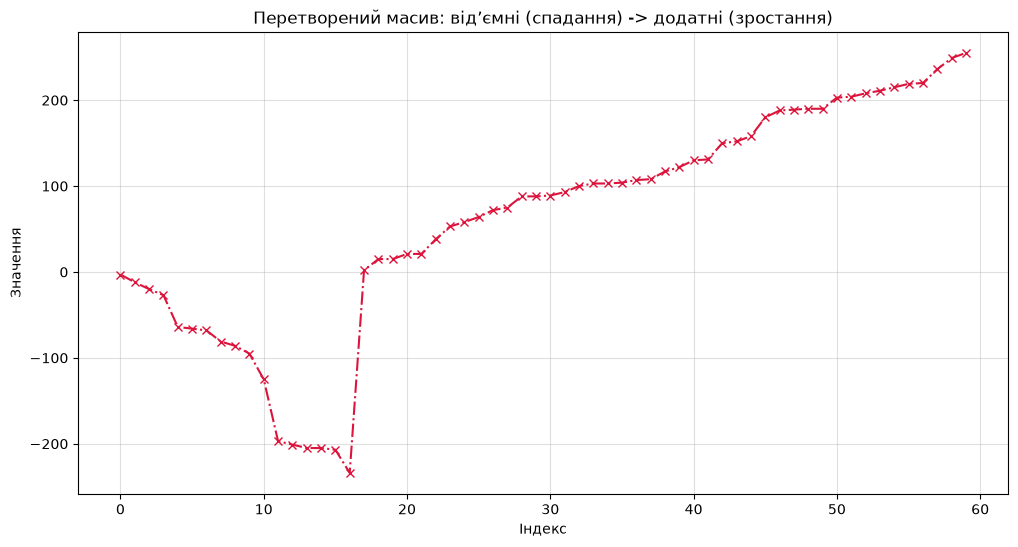

In [7]:
negative_sorted = np.sort(loaded_arr[loaded_arr < 0])[::-1]
positive_sorted = np.sort(loaded_arr[loaded_arr > 0])
zero_elements = loaded_arr[loaded_arr == 0]

transformed_arr = np.concatenate([negative_sorted, positive_sorted, zero_elements])

print("Перетворений масив:")
print(transformed_arr)

plt.figure(figsize=(12, 6))
plt.plot(transformed_arr, marker='x', linestyle='-.', color='crimson')
plt.title('Перетворений масив: від’ємні (спадання) -> додатні (зростання)')
plt.xlabel('Індекс')
plt.ylabel('Значення')
plt.grid(True, alpha=0.4)
plt.show()